<a href="https://colab.research.google.com/github/vishwasahuja62-maker/Machine-Learning-Labs/blob/main/Decision_Tree%2C_Naive_Bayes%2C_SVM%2C_KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 1.1 Decision Tree Implementation

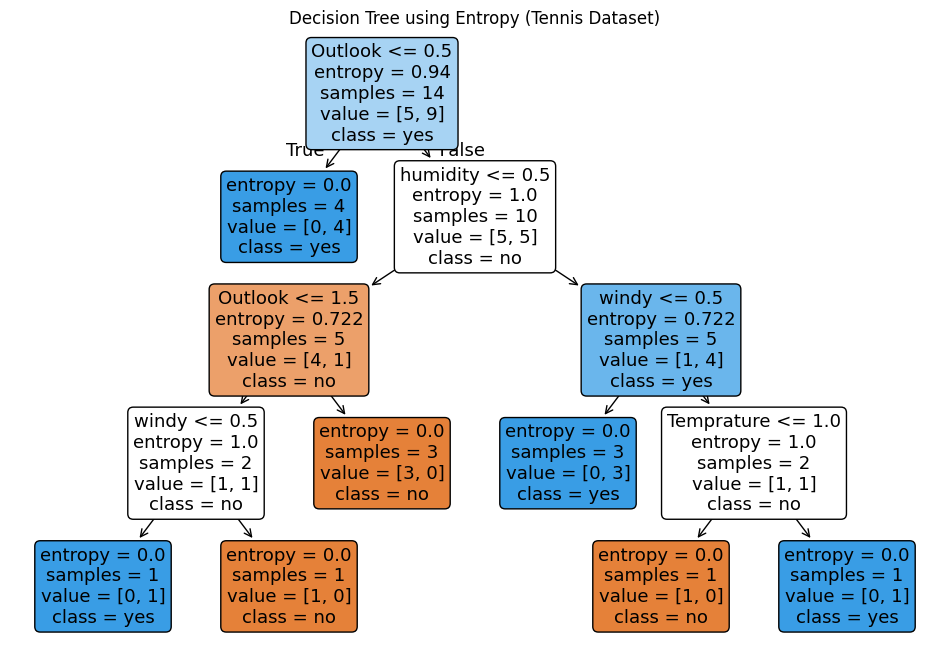

Decision Rules:

|--- Outlook <= 0.50
|   |--- class: 1
|--- Outlook >  0.50
|   |--- humidity <= 0.50
|   |   |--- Outlook <= 1.50
|   |   |   |--- windy <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- windy >  0.50
|   |   |   |   |--- class: 0
|   |   |--- Outlook >  1.50
|   |   |   |--- class: 0
|   |--- humidity >  0.50
|   |   |--- windy <= 0.50
|   |   |   |--- class: 1
|   |   |--- windy >  0.50
|   |   |   |--- Temprature <= 1.00
|   |   |   |   |--- class: 0
|   |   |   |--- Temprature >  1.00
|   |   |   |   |--- class: 1



In [ ]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text

# Step 1: Load dataset
df = pd.read_csv("Tennis.csv")   # make sure file is in same folder

# Step 2: Separate features and target
X = df.drop(columns=['play tennis'])
y = df['play tennis']

# Step 3: Encode categorical data
encoders = {}
for col in X.columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    encoders[col] = le

# Encode target variable
le_y = LabelEncoder()
y = le_y.fit_transform(y)

# Step 4: Train Decision Tree using ENTROPY
model = DecisionTreeClassifier(criterion='entropy', random_state=42)
model.fit(X, y)

# Step 5: Visualize Decision Tree
plt.figure(figsize=(12, 8))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=le_y.classes_,
    filled=True,
    rounded=True
)
plt.title("Decision Tree using Entropy (Tennis Dataset)")
plt.show()

# Step 6: Print decision rules
print("Decision Rules:\n")
rules = export_text(model, feature_names=list(X.columns))
print(rules)

### 1.2 Naive Bayes Implementation

In [ ]:
# Import libraries
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import CategoricalNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Step 1: Load dataset
df = pd.read_csv("Tennis.csv")

# Step 2: Separate features and target
X = df.drop(columns=['play tennis'])
y = df['play tennis']

# Step 3: Encode categorical columns
encoders = {}

for col in X.columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    encoders[col] = le

# Encode target column
le_y = LabelEncoder()
y = le_y.fit_transform(y)

# Step 4: Train Naive Bayes model
model = CategoricalNB()
model.fit(X, y)

# Step 5: Predict on training data
y_pred = model.predict(X)

# Step 6: Accuracy
print("Accuracy :", accuracy_score(y, y_pred))

# Step 7: Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y, y_pred))

# Step 8: Classification Report
print("\nClassification Report:")
print(classification_report(y, y_pred, target_names=le_y.classes_))

# Step 9: Example Prediction
# Example Input:
# Outlook = sunny
# Temperature = hot
# humidity = high
# windy = false

sample = pd.DataFrame({
    'Outlook': ['sunny'],
    'Temprature': ['hot'],
    'humidity': ['high'],
    'windy': ['false']
})

# Encode sample using same encoders
for col in sample.columns:
    sample[col] = encoders[col].transform(sample[col])

prediction = model.predict(sample)

print("\nPrediction for sample data:")
print(le_y.inverse_transform(prediction)[0])

Accuracy : 0.9285714285714286

Confusion Matrix:
[[4 1]
 [0 9]]

Classification Report:
              precision    recall  f1-score   support

          no       1.00      0.80      0.89         5
         yes       0.90      1.00      0.95         9

    accuracy                           0.93        14
   macro avg       0.95      0.90      0.92        14
weighted avg       0.94      0.93      0.93        14


Prediction for sample data:
no


### 1.3 SVM Implementation

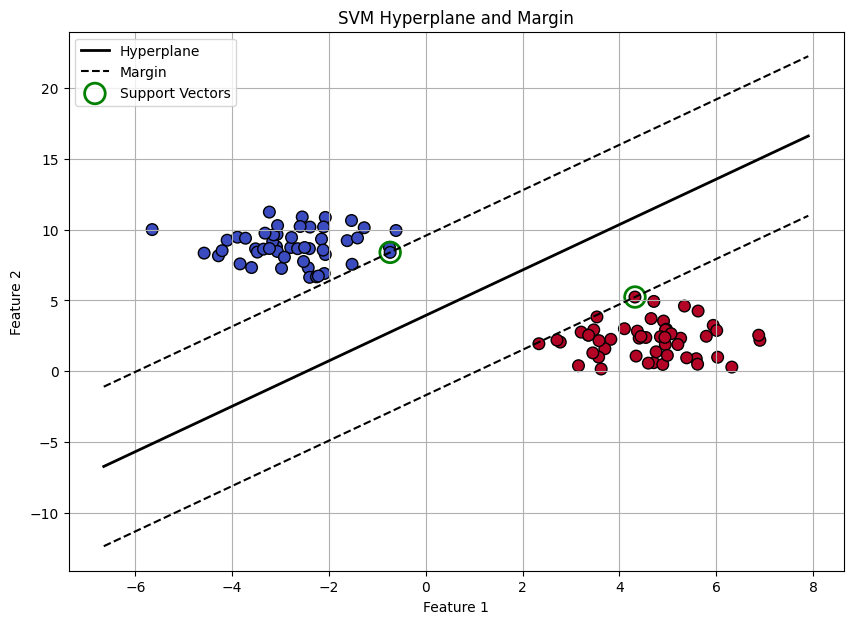

Hyperplane equation:
0.285x1 + -0.178x2 + 0.700 = 0
Margin width = 5.961


In [ ]:
# SVM implementation
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.datasets import make_blobs
# 1. Create sample 2D classification data
X, y = make_blobs(
    n_samples=100,
    centers=2,
    random_state=42,
    cluster_std=1.2
)
# 2. Train Linear SVM
model = SVC(kernel='linear', C=1.0)
model.fit(X, y)
# 3. Extract hyperplane parameters
w = model.coef_[0]
b = model.intercept_[0]
# Slope and intercept for plotting
slope = -w[0] / w[1]
intercept = -b / w[1]
# Margin lines:
# w.x + b = +1
# w.x + b = -1
# 4. Plot Data Points
plt.figure(figsize=(10, 7))
plt.scatter(
    X[:, 0], X[:, 1],
    c=y,
    cmap='coolwarm',
    s=70,
    edgecolors='k'
)
# 5. Plot Hyperplane and Margins
x_vals = np.linspace(X[:,0].min()-1, X[:,0].max()+1, 200)
# Main hyperplane
y_vals = slope * x_vals + intercept
# Upper margin: w.x + b = 1
y_margin_up = slope * x_vals + (1 - b) / w[1]

# Lower margin: w.x + b = -1
y_margin_down = slope * x_vals + (-1 - b) / w[1]

plt.plot(x_vals, y_vals, 'k-', linewidth=2, label='Hyperplane')
plt.plot(x_vals, y_margin_up, 'k--', linewidth=1.5, label='Margin')
plt.plot(x_vals, y_margin_down, 'k--', linewidth=1.5)
# 6. Highlight Support Vectors
plt.scatter(
    model.support_vectors_[:, 0],
    model.support_vectors_[:, 1],
    s=220,
    facecolors='none',
    edgecolors='green',
    linewidths=2,
    label='Support Vectors'
)
# 7. Labels
plt.title("SVM Hyperplane and Margin")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()
# 8. Print Equation
print("Hyperplane equation:")
print(f"{w[0]:.3f}x1 + {w[1]:.3f}x2 + {b:.3f} = 0")

margin = 2 / np.linalg.norm(w)
print("Margin width =", round(margin, 3))

### 1.4 KNN Implementation

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
# 1. Load Dataset
df = pd.read_csv("House Price Prediction Dataset.csv")
print("Dataset Preview:")
print(df.head())
# 2. Convert Categorical Columns to Numeric
for col in df.columns:
    if df[col].dtype == "object":
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])
# 3. Target Column = Last Column (House Price)
target_col = df.columns[-1]
median_price = df[target_col].median()
y = np.where(df[target_col] >= median_price, 1, 0)
# 4. Use First Two Features for Graph
feature1 = df.columns[0]
feature2 = df.columns[1]
X = df[[feature1, feature2]].values
# 5. Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42
)
# 6. Feature Scaling
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)
# 7. Train KNN Model
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
# 8. Prediction Accuracy
y_pred = knn.predict(X_test)
print("\nAccuracy:", round(accuracy_score(y_test, y_pred)*100,2), "%")

Dataset Preview:
   Id  Area  Bedrooms  Bathrooms  Floors  YearBuilt  Location  Condition  \
0   1  1360         5          4       3       1970  Downtown  Excellent   
1   2  4272         5          4       3       1958  Downtown  Excellent   
2   3  3592         2          2       3       1938  Downtown       Good   
3   4   966         4          2       2       1902  Suburban       Fair   
4   5  4926         1          4       2       1975  Downtown       Fair   

  Garage   Price  
0     No  149919  
1     No  424998  
2     No  266746  
3    Yes  244020  
4    Yes  636056  

Accuracy: 48.4 %
